<a href="https://colab.research.google.com/github/valearicano/machine-learning-valeria/blob/main/proyecto_final_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de este proyecto puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este proyecto pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11.

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [1]:
https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data

SyntaxError: invalid syntax (2677315249.py, line 1)

In [2]:
import pandas as pd

url = "https://www.datos.gov.co/resource/kgxf-xxbe.csv?$limit=50000"

df = pd.read_csv(url)

df.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20131,CR,SB11201310000414,URBANO,N,B,ACADÉMICO,3.118480e+11,3.118480e+11,11.0,...,Si,Si,Si,B+,94.0,88.0,NaN,NaN,NaN,NaN
1,20194,TI,SB11201940464873,RURAL,N,A,TÉCNICO/ACADÉMICO,1.410160e+11,2.410160e+11,41.0,...,Si,Si,Si,B1,71.0,66.0,70.0,65.0,69.0,339.0
2,20194,TI,SB11201940464873,RURAL,N,A,TÉCNICO/ACADÉMICO,1.410160e+11,2.410160e+11,41.0,...,Si,Si,Si,B1,71.0,66.0,70.0,65.0,69.0,339.0
3,20122,TI,SB11201220204399,URBANO,N,A,TÉCNICO/ACADÉMICO,1.631300e+11,1.631300e+11,63.0,...,Si,Si,No,A1,48.0,45.0,NaN,NaN,NaN,NaN
4,20132,TI,SB11201320464198,URBANO,N,A,TÉCNICO,1.190010e+11,1.190010e+11,19.0,...,Si,Si,Si,A-,43.0,52.0,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd
import requests

url = "https://www.datos.gov.co/resource/kgxf-xxbe.csv"

params = {
    "$select": "periodo,cole_area_ubicacion,cole_bilingue,cole_genero,cole_jornada,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,punt_global",
    "$where": "periodo IN ('20211','20212','20221','20222')",
    "$limit": 50000
}

respuesta = requests.get(url, params=params)

from io import StringIO

df = pd.read_csv(StringIO(respuesta.text))

df.head()

,periodo,cole_area_ubicacion,cole_bilingue,cole_genero,cole_jornada,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,punt_global
0,20211,RURAL,S,MIXTO,COMPLETA,Estrato 4,Si,Si,341
1,20211,URBANO,NaN,MIXTO,MAÑANA,Estrato 5,Si,Si,303
2,20211,URBANO,S,MIXTO,COMPLETA,NaN,NaN,NaN,362
3,20211,URBANO,N,MIXTO,MAÑANA,Estrato 3,Si,Si,342
4,20211,URBANO,S,MIXTO,COMPLETA,Estrato 6,Si,Si,352


## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

In [4]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [5]:
from io import StringIO

url = "https://www.datos.gov.co/resource/kgxf-xxbe.csv"

params = {
    "$select": "periodo,cole_area_ubicacion,cole_bilingue,cole_genero,cole_jornada,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,punt_global",
    "$where": "periodo IN ('20211','20212','20221','20222')",
    "$limit": 50000
}

respuesta = requests.get(url, params=params)

df = pd.read_csv(StringIO(respuesta.text))

df.head()

,periodo,cole_area_ubicacion,cole_bilingue,cole_genero,cole_jornada,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,punt_global
0,20211,RURAL,S,MIXTO,COMPLETA,Estrato 4,Si,Si,341
1,20211,URBANO,NaN,MIXTO,MAÑANA,Estrato 5,Si,Si,303
2,20211,URBANO,S,MIXTO,COMPLETA,NaN,NaN,NaN,362
3,20211,URBANO,N,MIXTO,MAÑANA,Estrato 3,Si,Si,342
4,20211,URBANO,S,MIXTO,COMPLETA,Estrato 6,Si,Si,352


In [6]:
df_filtrado = df.copy()

print(f"Número de filas en df_filtrado: {len(df_filtrado)}")
print(df_filtrado.head())

Número de filas en df_filtrado: 35577
   periodo cole_area_ubicacion cole_bilingue cole_genero cole_jornada  \
0    20211               RURAL             S       MIXTO     COMPLETA   
1    20211              URBANO           NaN       MIXTO       MAÑANA   
2    20211              URBANO             S       MIXTO     COMPLETA   
3    20211              URBANO             N       MIXTO       MAÑANA   
4    20211              URBANO             S       MIXTO     COMPLETA   

  fami_estratovivienda fami_tienecomputador fami_tieneinternet  punt_global  
0            Estrato 4                   Si                 Si          341  
1            Estrato 5                   Si                 Si          303  
2                  NaN                  NaN                NaN          362  
3            Estrato 3                   Si                 Si          342  
4            Estrato 6                   Si                 Si          352  


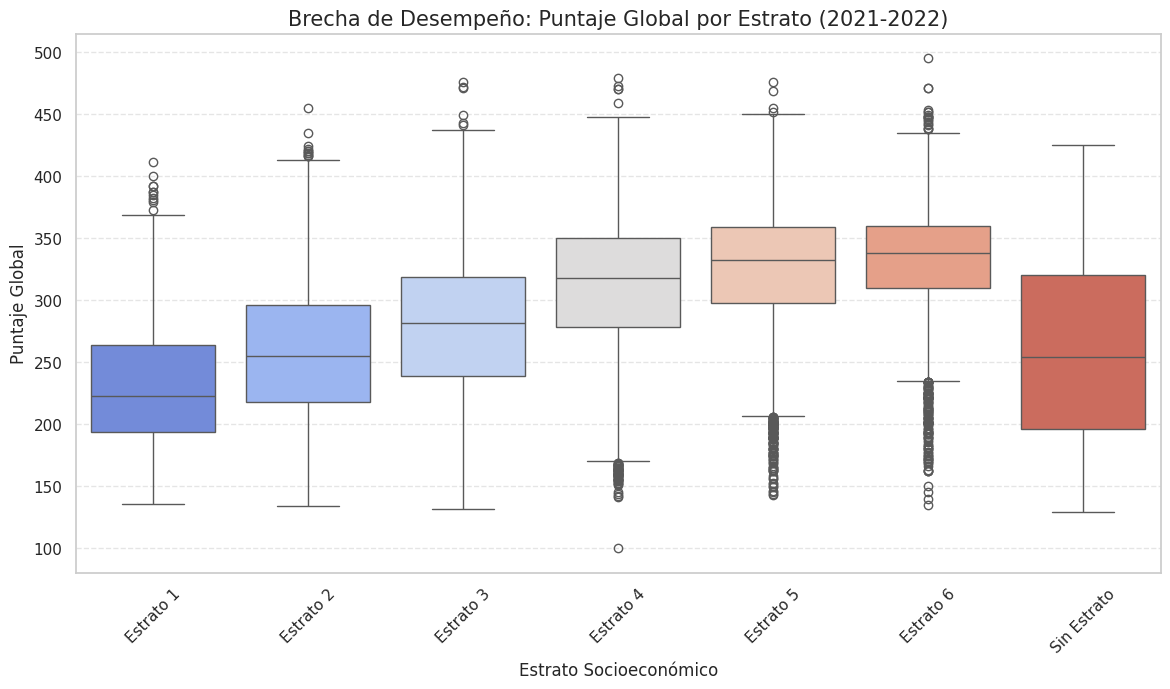


Puntaje Promedio por Estrato:
fami_estratovivienda
Estrato 1      232.47
Estrato 2      257.96
Sin Estrato    258.24
Estrato 3      279.04
Estrato 4      311.47
Estrato 5      325.30
Estrato 6      333.16
Name: punt_global, dtype: float64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_filtrado' in locals() and not df_filtrado.empty:
    plt.figure(figsize=(14, 7))

    # Debes ejecutar esto primero para que df_filtrado exista


    # Limpiamos nulos para la visualización del estrato
    df_plot = df_filtrado.dropna(subset=['fami_estratovivienda', 'punt_global'])

    # Corrección del FutureWarning y mejora de legibilidad
    sns.boxplot(data=df_plot.sort_values('fami_estratovivienda'),
            x='fami_estratovivienda',
            y='punt_global',
            hue='fami_estratovivienda', # Esto soluciona el warning
            palette='coolwarm',
            legend=False)

    plt.title('Brecha de Desempeño: Puntaje Global por Estrato (2021-2022)', fontsize=15)
    plt.xlabel('Estrato Socioeconómico', fontsize=12)
    plt.ylabel('Puntaje Global', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # Tabla comparativa de promedios
    print("\nPuntaje Promedio por Estrato:")
    print(df_plot.groupby('fami_estratovivienda')['punt_global'].mean().round(2).sort_values())
else:
    print('No hay datos filtrados para visualizar.')

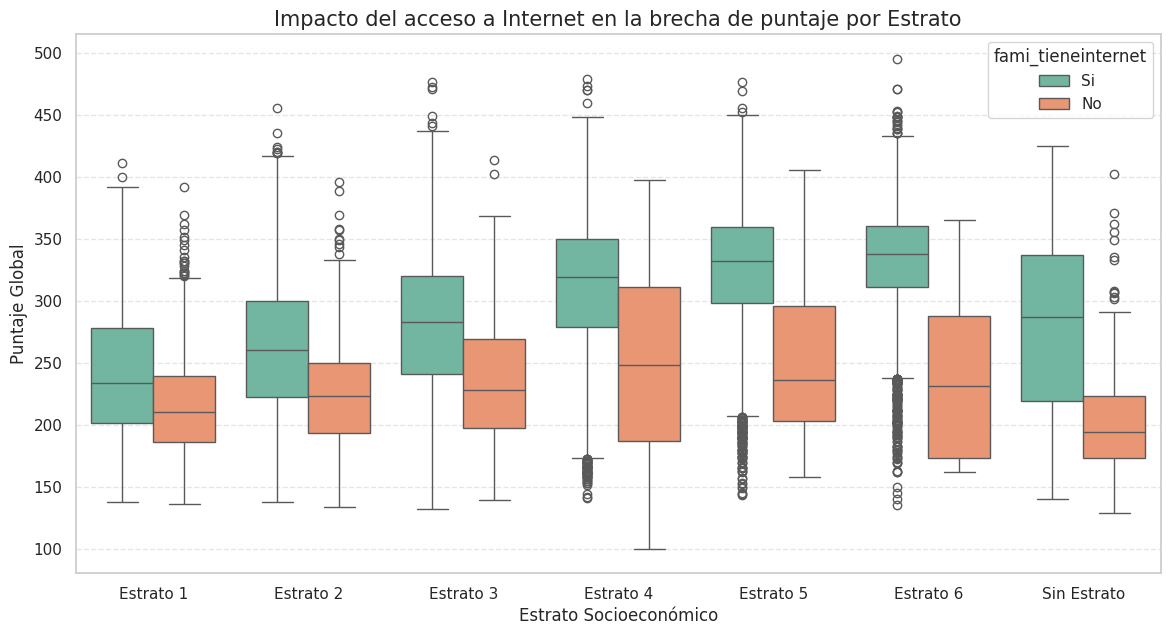

Promedio de puntaje según acceso a internet por estrato:
fami_tieneinternet            No          Si
fami_estratovivienda                        
Estrato 1             216.588305  241.530872
Estrato 2             225.394984  262.312500
Estrato 3             236.235808  280.348220
Estrato 4             248.850746  312.131048
Estrato 5             249.000000  325.707182
Estrato 6             234.800000  333.510260
Sin Estrato           207.298013  278.897638


In [8]:
# Graficar puntaje global por Estrato, diferenciando por acceso a Internet
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_plot.sort_values('fami_estratovivienda'),
            x='fami_estratovivienda',
            y='punt_global',
            hue='fami_tieneinternet', # Aquí añadimos la variable de internet
            palette='Set2')

plt.title('Impacto del acceso a Internet en la brecha de puntaje por Estrato', fontsize=15)
plt.xlabel('Estrato Socioeconómico', fontsize=12)
plt.ylabel('Puntaje Global', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Comparativa numérica de promedios con Internet
print("Promedio de puntaje según acceso a internet por estrato:")
print(df_plot.groupby(['fami_estratovivienda', 'fami_tieneinternet'])['punt_global'].mean().unstack())

In [9]:
# Estadísticas completas por estrato
print(df_plot.groupby('fami_estratovivienda')['punt_global'].agg(['mean', 'median', 'std', 'var']).round(2))

                        mean  median    std      var
fami_estratovivienda                                
Estrato 1             232.47   223.0  50.12  2511.56
Estrato 2             257.96   255.0  52.52  2758.23
Estrato 3             279.04   282.0  54.06  2922.28
Estrato 4             311.47   318.0  53.13  2823.22
Estrato 5             325.30   332.0  48.21  2323.91
Estrato 6             333.16   338.0  42.43  1800.44
Sin Estrato           258.24   254.5  71.37  5093.16


Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

In [39]:
# 1. Limpieza de filas con nulos
df_limpio = df_filtrado.dropna(subset=['fami_tieneinternet', 'punt_global']).copy()

# 2. TRANSFORMACIÓN CRÍTICA: Convertir "Si" y "No" a números
df_limpio['internet_num'] = df_limpio['fami_tieneinternet'].map({'Si': 1, 'No': 0})

# 3. Preparar variables usando la columna numérica que acabamos de crear
X1 = df_limpio[['internet_num']]
y = (df_limpio['punt_global'] > 370).astype(int)

# 4. Entrenamiento
modelo_internet = LogisticRegression()
modelo_internet.fit(X1, y)

print("¡Modelo entrenado correctamente!")

¡Modelo entrenado correctamente!


In [58]:
# Mantenemos tu definición original de la beca
df_filtrado['beca'] = df_filtrado.apply(
    lambda row: 1 if row['internet_num'] == 1 and row['punt_global'] > 370 else 0,
    axis=1
)

# --- AQUÍ ESTÁ LA SOLUCIÓN: Limpiamos los nulos de tus variables elegidas ---
# Filtramos solo las filas donde tenemos datos válidos para el modelo
df_para_modelo = df_filtrado.dropna(subset=['internet_num', 'beca'])

# Usamos el dataframe limpio para X e y
X_int = df_para_modelo[['internet_num']]
y = df_para_modelo['beca']

# Ahora el modelo entrenará sin errores
modelo_internet = LogisticRegression()
modelo_internet.fit(X_int, y)

# Imprime las probabilidades
print("Probabilidad sin internet:", modelo_internet.predict_proba([[0]])[0][1])
print("Probabilidad con internet:", modelo_internet.predict_proba([[1]])[0][1])

Probabilidad sin internet: 0.0019728201292316355
Probabilidad con internet: 0.08901095229315292


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [56]:
# 1. Asegúrate de tener la columna numérica lista (esto lo habías hecho antes)
df_filtrado['internet_num'] = df_filtrado['fami_tieneinternet'].map({'Si': 1, 'No': 0})

# 2. Definimos la meta (Beca = 1 si cumple ambas condiciones)
# Usamos un lambda para evaluar la lógica combinada
df_filtrado['beca'] = df_filtrado.apply(
    lambda row: 1 if (row['internet_num'] == 1 and row['punt_global'] > 370) else 0,
    axis=1
)

# 3. LIMPIEZA OBLIGATORIA: Quitamos los nulos para que el modelo no falle
df_limpio = df_filtrado.dropna(subset=['punt_global', 'internet_num', 'beca'])

# 4. Preparar variables numéricas para el modelo
X_completo = df_limpio[['punt_global', 'internet_num']]
y = df_limpio['beca']

# 5. Entrenar modelo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_completo, y, test_size=0.3, random_state=42)

modelo_completo = LogisticRegression()
modelo_completo.fit(X_train, y_train)

# 6. Probemos la lógica: ¿Qué pasa si tiene internet (1) y sacó 380 puntos?
ejemplo = [[380, 1]]
probabilidad = modelo_completo.predict_proba(ejemplo)[0][1]

print(f"Probabilidad de obtener beca con 380 puntos e internet: {probabilidad:.2%}")

Probabilidad de obtener beca con 380 puntos e internet: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Tabla comparativa de validación (Primeros 10 casos):
       Real  Predicción
30296     0           0
3946      0           0
24467     0           0
7617      0           0
14029     0           0
28205     0           0
33836     0           0
14937     0           0
30437     0           0
29350     1           1


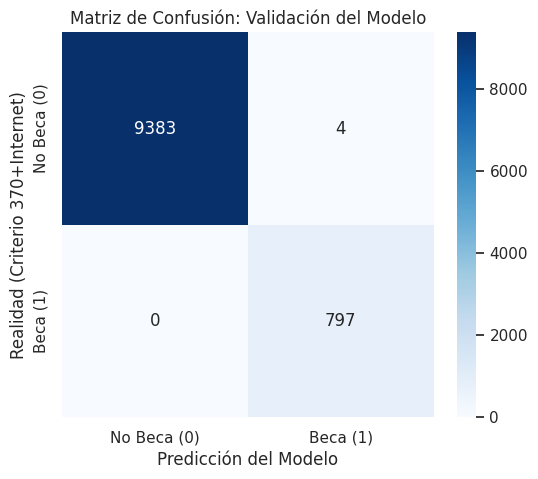

In [57]:
# --- CELDA DE EVALUACIÓN FINAL ---

# 1. Aseguramos las predicciones (si no las has corrido, hazlo aquí)
# Suponiendo que ya entrenaste 'modelo_completo' y definiste 'X_test' y 'y_test'
y_pred = modelo_completo.predict(X_test)

# 2. Crear la tabla comparativa de los primeros 10 resultados
resultados = pd.DataFrame({'Real': y_test, 'Predicción': y_pred})
print("Tabla comparativa de validación (Primeros 10 casos):")
print(resultados.head(10))

# 3. Generar la Matriz de Confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Graficar la matriz
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Beca (0)', 'Beca (1)'],
            yticklabels=['No Beca (0)', 'Beca (1)'])

plt.title('Matriz de Confusión: Validación del Modelo')
plt.ylabel('Realidad (Criterio 370+Internet)')
plt.xlabel('Predicción del Modelo')
plt.show()

## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [55]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aseguramos que la lista de estratos sea correcta
estratos = sorted(df_filtrado['fami_estratovivienda'].dropna().unique())

# 2. Creamos el menú desplegable (Dropdown)
selector = widgets.Dropdown(
    options=estratos,
    value=estratos[0],
    description='Estrato:',
)

# 3. Creamos el contenedor donde se dibujará la gráfica
output = widgets.Output()

# 4. Esta es tu función (asegúrate de tenerla tal cual la definiste)
def actualizar_grafico(change):
    with output:
        clear_output(wait=True) # Esto limpia la gráfica anterior para mostrar la nueva
        estrato_sel = change['new']
        data_sub = df_filtrado[df_filtrado['fami_estratovivienda'] == estrato_sel]

        plt.figure(figsize=(10, 5))
        sns.histplot(data_sub['punt_global'], kde=True, color='skyblue')
        plt.axvline(data_sub['punt_global'].mean(), color='red', linestyle='--')
        plt.title(f'Distribución de Puntajes - {estrato_sel}')
        plt.show()

        internet_stats = data_sub['fami_tieneinternet'].value_counts(normalize=True) * 100
        print(f"Porcentaje de acceso a internet en {estrato_sel}:")
        print(internet_stats)

# 5. CONEXIÓN: Decimos al selector que llame a la función cuando cambie
selector.observe(actualizar_grafico, names='value')

# 6. MOSTRAR: Esto es lo que hace que aparezca en tu pantalla
display(selector)
display(output)

# 7. Disparo inicial para que muestre algo apenas corras el código
actualizar_grafico({'new': estratos[0]})

Dropdown(description='Estrato:', options=('Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Es…

Output()

## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py